In [35]:
!pip install sentence-transformers matplotlib pandas seaborn

from sentence_transformers import SentenceTransformer, util
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
# 10 sentences
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler bowled a fast yorker that crashed into the stumps",
    "The team won the cricket match by six wickets",
    "Fielders saved crucial runs near the boundary",

    # Cooking
    "The chef prepared a delicious pasta dish",
    "Boil the vegetables before adding spices",
    "Baking requires precise temperature control",

    # Cybersecurity
    "Strong passwords and multi-factor authentication help prevent unauthorized access",
    "Firewalls protect systems from malicious traffic coming from unknown IP addresses",
    "Encryption secures sensitive data from attackers"
]

In [37]:
# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
embeddings = model.encode(sentences)

# Compute cosine similarity
similarity_matrix = util.cos_sim(embeddings,embeddings)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
# 10x10 matrix
similarity_df = pd.DataFrame(
    similarity_matrix.cpu().numpy(),
    index=[f"S{i+1}" for i in range(len(sentences))],
    columns=[f"S{i+1}" for i in range(len(sentences))]
)

similarity_df.round(3)

,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10
S1,1.000,0.438,0.587,0.338,-0.008,0.039,0.095,-0.034,0.050,0.052
S2,0.438,1.000,0.501,0.415,0.149,0.029,0.045,-0.045,0.055,0.066
S3,0.587,0.501,1.000,0.198,0.071,0.057,0.020,-0.081,0.067,0.085
S4,0.338,0.415,0.198,1.000,-0.001,0.016,0.028,0.055,0.116,0.115
S5,-0.008,0.149,0.071,-0.001,1.000,0.286,0.237,-0.042,0.127,0.098
S6,0.039,0.029,0.057,0.016,0.286,1.000,0.144,-0.027,0.007,0.033
S7,0.095,0.045,0.020,0.028,0.237,0.144,1.000,-0.013,0.059,0.108
S8,-0.034,-0.045,-0.081,0.055,-0.042,-0.027,-0.013,1.000,0.187,0.330
S9,0.050,0.055,0.067,0.116,0.127,0.007,0.059,0.187,1.000,0.362
S10,0.052,0.066,0.085,0.115,0.098,0.033,0.108,0.330,0.362,1.000


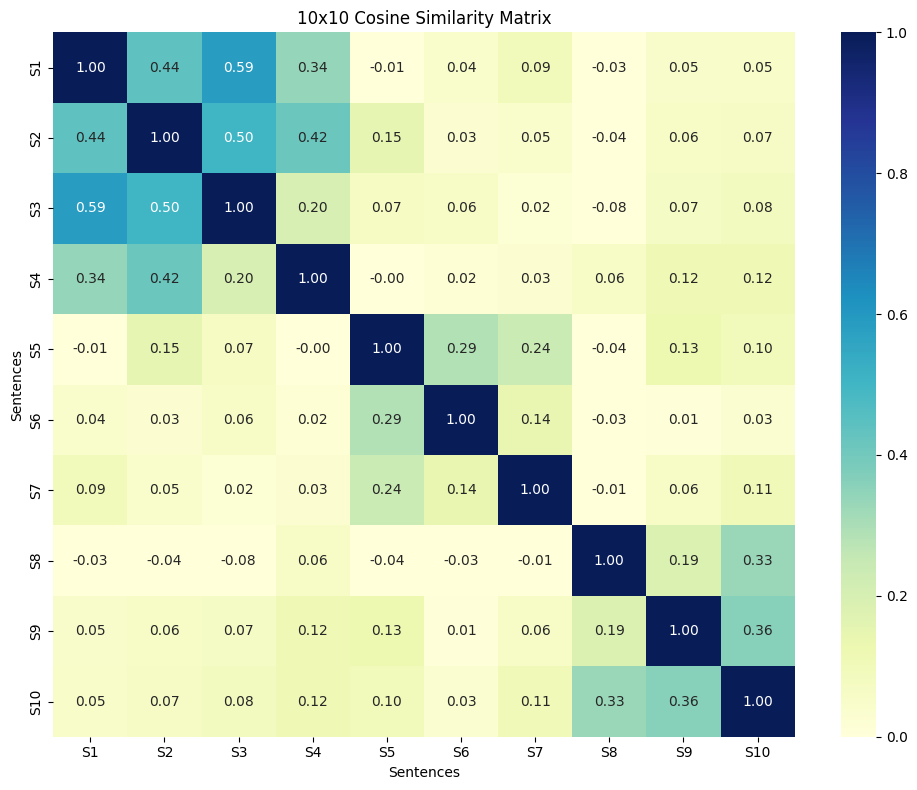

In [39]:
# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_df, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("10x10 Cosine Similarity Matrix")
plt.xlabel("Sentences")
plt.ylabel("Sentences")
plt.tight_layout()
plt.show()


In [40]:
query = "The bowler took three wickets in one over"

# Encode query
query_embedding = model.encode(query, convert_to_tensor=True)

# Compute similarity with all sentences
query_similarities = util.cos_sim(query_embedding, embeddings).cpu().numpy().flatten()

# Get top 2 indices
top_2_idx = query_similarities.argsort()[::-1][:2]

# Print results
print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for rank, idx in enumerate(top_2_idx, start=1):
    print(f"{rank}. {sentences[idx]}")
    print(f"   Similarity score: {query_similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

1. The team won the cricket match by six wickets
   Similarity score: 0.7332

2. The bowler bowled a fast yorker that crashed into the stumps
   Similarity score: 0.6368

